# 06 - Customer Profiling & Marketing Insights

El objetivo de este notebook es interpretar desde una perspectiva de negocio los segmentos de clientes identificados mediante K-Means y relacionarlos con la segmentación RFM desarrollada previamente.

Una vez construidos los clusters, el análisis se amplía combinando las variables
utilizadas por el modelo con características adicionales que no participaron
directamente en el clustering, como nivel educativo, estado civil, categorías
de producto, canales de compra y respuesta a campañas de marketing.

Finalmente, se compararán las segmentaciones K-Means y RFM para estudiar qué
información aporta cada metodología y construir perfiles de clientes que puedan
traducirse en acciones de marketing.

## Estructura

1. Carga de datos y reconstrucción de clusters
2. Perfil general de los clusters
3. Comportamiento de compra
4. Respuesta de marketing
5. Comparación entre K-Means y RFM
6. Definición de perfiles de cliente
7. Recomendaciones de marketing
8. Conclusiones

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 1. Carga de datos y reconstrucción de clusters

Se utiliza el dataset preparado anteriormente y se reconstruye la segmentación
K-Means utilizando exactamente las mismas decisiones metodológicas establecidas
en el análisis de clustering.

Los cuatro clientes con valores extremos de edad o ingresos se excluyen
únicamente de la muestra utilizada para K-Means, manteniendo intacto el dataset
preparado original.

El modelo utiliza seis características estandarizadas y una solución final de
tres clusters.

In [6]:
DATA_PATH = Path("../data/processed/customer_segmentation_prepared.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Dt_Customer"]
)

df.shape

(2240, 33)

### 1.1 Reconstrucción de la segmentación K-Means

Para mantener la coherencia con el análisis anterior, se aplican los mismos
criterios utilizados durante la construcción del modelo.

Se excluyen únicamente de la muestra de clustering los tres clientes con edades
superiores a 100 años y el cliente con un ingreso superior a 200.000. A
continuación, se seleccionan las mismas seis variables, se estandarizan y se
reproduce el modelo K-Means con tres clusters.

Esta reconstrucción permite disponer de las etiquetas de cluster necesarias
para el perfilado sin modificar el dataset preparado original.

In [7]:
extreme_mask = (
    (df["Age"] > 100)
    | (df["Income"] > 200000)
)

df_cluster = df.loc[~extreme_mask].copy()

clustering_features = [
    "Age",
    "Income",
    "Children",
    "CustomerTenure",
    "Recency",
    "TotalSpend"
]

X = df_cluster[clustering_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

In [8]:
cluster_check = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

cluster_check["Percentage"] = (
    cluster_check["Customers"] / len(df_cluster) * 100
).round(2)

cluster_check

,Customers,Percentage
Cluster,,
0,715,31.98
1,803,35.91
2,718,32.11


## 2. Perfil general de los clusters

Una vez reconstruida la segmentación, se analiza la composición de los tres
clusters para identificar sus principales diferencias.

El objetivo de esta sección es caracterizar inicialmente los grupos mediante su
tamaño y sus variables sociodemográficas. Posteriormente, el análisis se
ampliará con el comportamiento de compra y la respuesta de marketing.

### 2.1 Tamaño de los clusters

En primer lugar, se analiza el número de clientes y el peso relativo de cada
cluster dentro de la muestra utilizada para la segmentación.

In [9]:
cluster_distribution = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

cluster_distribution["Percentage"] = (
    cluster_distribution["Customers"]
    / len(df_cluster)
    * 100
).round(2)

cluster_distribution

,Customers,Percentage
Cluster,,
0,715,31.98
1,803,35.91
2,718,32.11


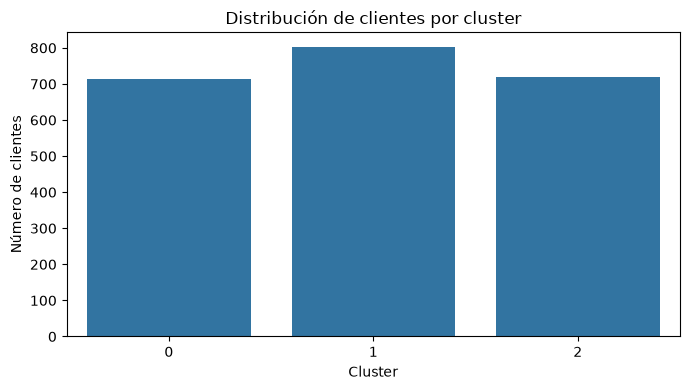

In [10]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df_cluster,
    x="Cluster"
)

plt.title("Distribución de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")

plt.tight_layout()
plt.show()

### 2.2 Perfil sociodemográfico

Se comparan las principales características sociodemográficas de los clientes
para identificar diferencias de edad, ingresos y composición del hogar entre
los clusters.

`Age`, `Income` y `Children` formaron parte de las variables utilizadas por
K-Means, por lo que permiten describir algunas de las dimensiones que
contribuyeron directamente a la formación de los clusters. `Education` y
`Marital_Status`, en cambio, no participaron en el modelo y se utilizan como
variables adicionales de perfilado.

In [11]:
demographic_features = [
    "Age",
    "Income",
    "Children"
]

demographic_profile = (
    df_cluster
    .groupby("Cluster")[demographic_features]
    .mean()
    .round(2)
)

demographic_profile

,Age,Income,Children
Cluster,,,
0,36.94,31945.28,0.84
1,46.51,73388.23,0.40
2,51.66,47917.50,1.67


In [12]:
education_profile = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Education"],
    normalize="index"
).mul(100).round(1)

education_profile

Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
0,12.7,7.4,50.8,14.5,14.5
1,7.8,0.0,53.1,15.1,24.0
2,6.5,0.1,46.9,20.2,26.2


In [13]:
marital_profile = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Marital_Status"],
    normalize="index"
).mul(100).round(1)

marital_profile

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Cluster,,,,,,,,
0,0.0,0.1,7.8,40.8,25.0,24.5,1.4,0.3
1,0.2,0.0,11.8,37.1,21.5,24.7,4.6,0.0
2,0.0,0.3,11.1,38.2,17.7,28.6,4.2,0.0


### 2.3 Interpretación del perfil sociodemográfico

Los clusters presentan diferencias claras en edad, nivel de ingresos y
composición del hogar.

El **Cluster 0** corresponde al grupo más joven, con una edad media de 36,94
años y unos ingresos medios de aproximadamente 31.945. Presenta 0,84 hijos de
media, situándose entre los otros dos grupos en términos de composición del
hogar.

El **Cluster 1** presenta los mayores ingresos, con una media de aproximadamente
73.388, y una edad media de 46,51 años. También registra el menor número de
hijos, con 0,40 de media. Estas características refuerzan su diferenciación como
el grupo con mayor capacidad económica.

El **Cluster 2** agrupa a los clientes de mayor edad, con una media de 51,66
años, y presenta la mayor presencia de hijos en el hogar, con 1,67 de media.
Sus ingresos, aproximadamente 47.918, se sitúan entre los otros dos clusters.

En cuanto al nivel educativo, `Graduation` constituye la categoría más frecuente
en los tres grupos. Los Clusters 1 y 2 presentan una mayor proporción de
clientes con `PhD` que el Cluster 0, mientras que este último muestra una mayor
presencia relativa de `2n Cycle` y `Basic`.

Las diferencias en estado civil son menos pronunciadas. `Married` y `Together`
constituyen las categorías predominantes en los tres clusters. El Cluster 0
presenta una mayor proporción de clientes `Single`, mientras que el Cluster 2
muestra una mayor presencia relativa de `Together`.

En conjunto, las principales diferencias sociodemográficas entre los clusters
se encuentran en la edad, los ingresos y el número de hijos. Educación y estado
civil aportan información adicional para el perfilado, pero muestran una
capacidad de diferenciación menor.

## 3. Comportamiento de compra

Una vez caracterizado el perfil sociodemográfico de los clusters, se analiza su
comportamiento de compra.

El objetivo es estudiar si los segmentos presentan diferencias en las categorías
de producto consumidas, los canales utilizados y la intensidad de compra. Estas
variables no participaron directamente en la construcción de K-Means, aunque
algunas de ellas están relacionadas con `TotalSpend`, utilizado por el modelo.

### 3.1 Gasto por categoría de producto

Se analiza el gasto medio de cada cluster en las seis categorías de producto
disponibles en el dataset para identificar diferencias en la composición del
consumo.

In [14]:
product_features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_profile = (
    df_cluster
    .groupby("Cluster")[product_features]
    .mean()
    .round(2)
)

product_profile

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,56.54,9.15,37.72,13.64,9.36,24.18
1,635.49,56.46,379.87,81.18,58.41,74.98
2,180.09,9.57,57.61,12.52,9.69,29.04


In [15]:
product_mix = (
    product_profile
    .div(product_profile.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

product_mix

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,37.5,6.1,25.0,9.1,6.2,16.1
1,49.4,4.4,29.5,6.3,4.5,5.8
2,60.3,3.2,19.3,4.2,3.2,9.7


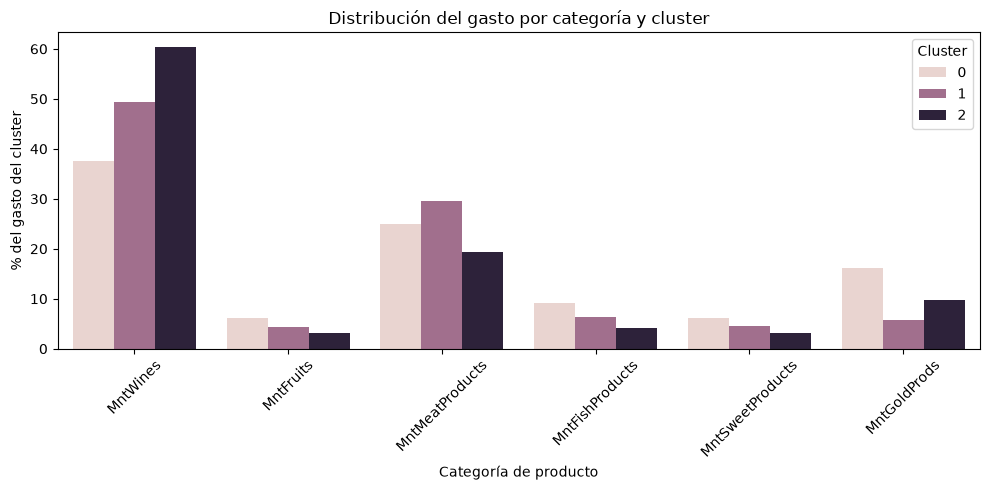

In [16]:
product_mix_plot = (
    product_mix
    .reset_index()
    .melt(
        id_vars="Cluster",
        var_name="Product",
        value_name="Percentage"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=product_mix_plot,
    x="Product",
    y="Percentage",
    hue="Cluster"
)

plt.title("Distribución del gasto por categoría y cluster")
plt.xlabel("Categoría de producto")
plt.ylabel("% del gasto del cluster")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.1.1 Interpretación del gasto por categoría

El gasto absoluto presenta diferencias muy pronunciadas entre los clusters. El
**Cluster 1** registra el mayor gasto medio en todas las categorías de producto,
destacando especialmente vinos (635,49) y productos cárnicos (379,87). El
**Cluster 0** presenta los niveles de gasto más bajos, mientras que el
**Cluster 2** ocupa una posición intermedia.

Sin embargo, el análisis del mix de gasto permite identificar diferencias que
no dependen únicamente del volumen total consumido.

El **Cluster 0** presenta la cesta más diversificada. Aunque vinos (37,5 %) y
carne (25,0 %) concentran la mayor parte del gasto, los productos Gold
representan un 16,1 %, una proporción considerablemente superior a la observada
en los otros grupos.

El **Cluster 1** concentra aproximadamente la mitad de su gasto en vinos
(49,4 %) y un 29,5 % en productos cárnicos. Aunque su gasto absoluto es elevado
en todas las categorías, proporcionalmente presenta una fuerte orientación
hacia estas dos categorías.

El **Cluster 2** muestra la mayor concentración de gasto en una única categoría:
los vinos representan el 60,3 % de su consumo. Los productos cárnicos ocupan
una segunda posición con el 19,3 %, mientras que el resto de categorías tienen
un peso relativamente reducido.

Por tanto, los clusters no solo difieren en el volumen total de gasto, sino
también en su composición. El Cluster 0 presenta un consumo más diversificado,
el Cluster 1 combina un elevado gasto con una fuerte presencia de vinos y carne,
y el Cluster 2 muestra una especial concentración en vinos.

### 3.2 Compras por canal

Se analiza el número medio de compras realizadas a través de los principales
canales disponibles: web, catálogo y tienda física.

Estas variables no participaron directamente en el entrenamiento de K-Means,
por lo que permiten ampliar la caracterización conductual de los segmentos.

In [17]:
channel_features = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_profile = (
    df_cluster
    .groupby("Cluster")[channel_features]
    .mean()
    .round(2)
)

channel_profile

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Cluster,,,
0,2.66,0.77,3.56
1,5.65,5.44,8.53
2,3.77,1.45,4.96


In [18]:
channel_mix = (
    channel_profile
    .div(channel_profile.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

channel_mix

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Cluster,,,
0,38.1,11.0,50.9
1,28.8,27.7,43.5
2,37.0,14.2,48.7


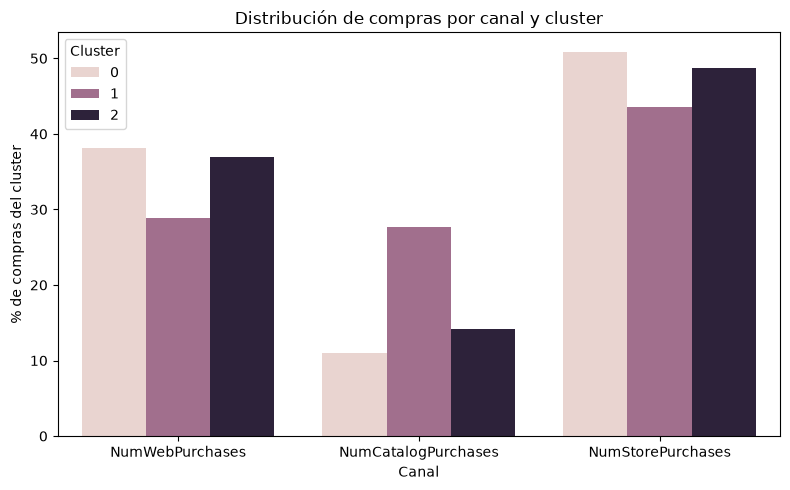

In [19]:
channel_mix_plot = (
    channel_mix
    .reset_index()
    .melt(
        id_vars="Cluster",
        var_name="Channel",
        value_name="Percentage"
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_mix_plot,
    x="Channel",
    y="Percentage",
    hue="Cluster"
)

plt.title("Distribución de compras por canal y cluster")
plt.xlabel("Canal")
plt.ylabel("% de compras del cluster")

plt.tight_layout()
plt.show()

### 3.2.1 Interpretación de las compras por canal

El volumen de compras presenta diferencias importantes entre los clusters. El
**Cluster 1** registra la mayor actividad en todos los canales, con una media de
5,65 compras web, 5,44 compras por catálogo y 8,53 compras en tienda.

El **Cluster 0** presenta la menor intensidad de compra en los tres canales,
mientras que el **Cluster 2** ocupa una posición intermedia.

La composición de las compras por canal permite observar diferencias adicionales.
La tienda física constituye el principal canal en los tres clusters, aunque su
peso varía entre grupos.

Los **Clusters 0 y 2** presentan una estructura relativamente similar. En ambos,
aproximadamente la mitad de las compras se realizan en tienda física y alrededor
del 37-38 % mediante web. El catálogo tiene un peso considerablemente menor,
representando el 11,0 % y el 14,2 %, respectivamente.

El **Cluster 1** muestra una distribución más equilibrada entre canales. La
tienda continúa siendo el canal principal (43,5 %), pero el catálogo representa
un 27,7 % de sus compras, una proporción aproximadamente dos veces superior a la
del resto de clusters. Las compras web representan el 28,8 %.

Por tanto, el Cluster 1 destaca no solo por una mayor intensidad de compra, sino
también por una utilización más equilibrada de los diferentes canales. Los
Clusters 0 y 2 presentan un comportamiento más concentrado en tienda y web, con
una participación relativamente reducida del catálogo.

### 3.3 Intensidad de compra, descuentos y actividad web

Para completar el análisis del comportamiento de compra se estudian la
intensidad total de compra, el uso de promociones y la actividad digital.

`TotalPurchases` resume las compras realizadas mediante web, catálogo y tienda.
`NumDealsPurchases` recoge las compras efectuadas utilizando descuentos, mientras
que `NumWebVisitsMonth` permite aproximar el nivel de actividad del cliente en
el canal digital.

Estas variables permiten distinguir entre volumen de compra, utilización de
promociones y navegación web.

In [20]:
behavior_features = [
    "TotalPurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth"
]

behavior_profile = (
    df_cluster
    .groupby("Cluster")[behavior_features]
    .mean()
    .round(2)
)

behavior_profile

,TotalPurchases,NumDealsPurchases,NumWebVisitsMonth
Cluster,,,
0,6.99,2.06,6.68
1,19.62,1.78,3.60
2,10.17,3.20,5.88


In [21]:
df_cluster["DealPurchaseRatio"] = (
    df_cluster["NumDealsPurchases"]
    / df_cluster["TotalPurchases"].replace(0, pd.NA)
)

deal_profile = (
    df_cluster
    .groupby("Cluster")["DealPurchaseRatio"]
    .mean()
    .mul(100)
    .round(1)
    .rename("DealPurchaseRatio (%)")
    .to_frame()
)

deal_profile

,DealPurchaseRatio (%)
Cluster,
0,32.6
1,9.3
2,34.4


### 3.3.1 Interpretación de la intensidad de compra, descuentos y actividad web

Los clusters presentan diferencias relevantes en intensidad de compra, uso de
descuentos y actividad web.

El **Cluster 1** muestra la mayor intensidad de compra, con una media de 19,62
compras por cliente. Sin embargo, registra el menor número de compras con
descuento (1,78) y la menor actividad web, con 3,60 visitas mensuales de media.

Además, las compras con descuento representan aproximadamente un 9,3 % de sus
compras a nivel cliente, una proporción considerablemente inferior a la
observada en los otros grupos. Este patrón sugiere una menor dependencia
relativa de las promociones dentro de su comportamiento de compra.

El **Cluster 0** presenta la menor intensidad de compra, con 6,99 compras de
media, a pesar de registrar la mayor actividad web, con 6,68 visitas mensuales.
Las compras con descuento representan aproximadamente un 32,6 % de sus compras,
indicando un peso relativo de las promociones superior al del Cluster 1.

El **Cluster 2** ocupa una posición intermedia en intensidad de compra, con
10,17 compras de media, pero registra el mayor número de compras con descuento
(3,20). El ratio medio de compras con descuento alcanza el 34,4 %, el valor más
elevado de los tres grupos. También presenta una actividad web relativamente
alta, con 5,88 visitas mensuales.

En conjunto, el Cluster 1 combina una elevada intensidad de compra con menor
actividad web y menor peso relativo de los descuentos. Por el contrario, los
Clusters 0 y 2 visitan la web con mayor frecuencia y presentan una proporción
considerablemente superior de compras asociadas a promociones.

Estos resultados son descriptivos y no permiten concluir que los descuentos o
las visitas web causen las diferencias observadas en el comportamiento de compra.

## 4. Respuesta de marketing

Además del comportamiento de compra, el dataset contiene información sobre la
aceptación de diferentes campañas de marketing.

Se analiza tanto el historial de aceptación de las cinco campañas anteriores
como la respuesta a la última campaña disponible. Estas variables no
participaron directamente en la construcción de K-Means y permiten ampliar la
interpretación comercial de los clusters.

### 4.1 Aceptación histórica de campañas

Se compara la tasa de aceptación de las cinco campañas anteriores para analizar
si los clusters presentan diferencias consistentes en su respuesta histórica a
las acciones de marketing.

In [22]:
campaign_features = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

campaign_profile = (
    df_cluster
    .groupby("Cluster")[campaign_features]
    .mean()
    .mul(100)
    .round(1)
)

campaign_profile

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster,,,,,
0,0.3,0.0,8.3,1.1,0.0
1,16.4,3.4,8.0,14.1,20.0
2,1.4,0.4,5.6,6.4,0.1


In [23]:
campaign_acceptance_profile = (
    df_cluster
    .groupby("Cluster")["CampaignAcceptances"]
    .mean()
    .round(2)
    .rename("AverageCampaignAcceptances")
    .to_frame()
)

campaign_acceptance_profile

,AverageCampaignAcceptances
Cluster,
0,0.10
1,0.62
2,0.14


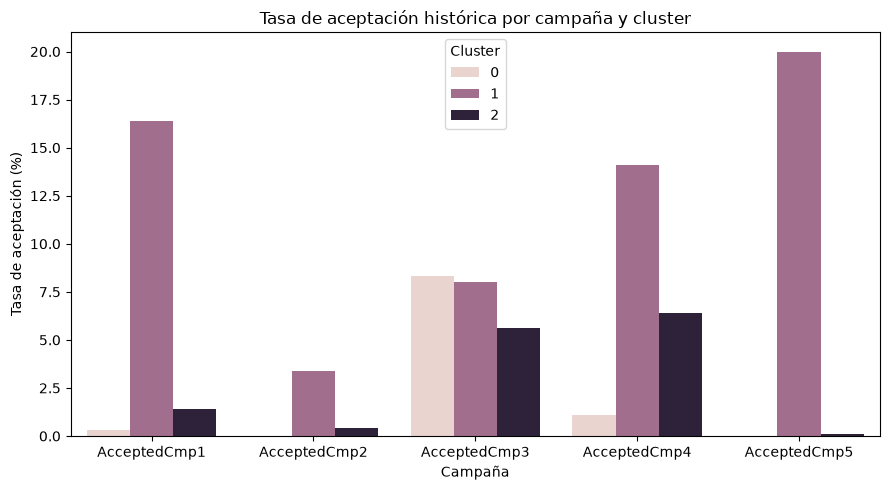

In [24]:
campaign_plot = (
    campaign_profile
    .reset_index()
    .melt(
        id_vars="Cluster",
        var_name="Campaign",
        value_name="AcceptanceRate"
    )
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=campaign_plot,
    x="Campaign",
    y="AcceptanceRate",
    hue="Cluster"
)

plt.title("Tasa de aceptación histórica por campaña y cluster")
plt.xlabel("Campaña")
plt.ylabel("Tasa de aceptación (%)")

plt.tight_layout()
plt.show()

### 4.1.1 Interpretación de la aceptación histórica de campañas

La respuesta histórica a las campañas presenta diferencias importantes entre
los clusters.

El **Cluster 1** registra la mayor aceptación acumulada, con una media de 0,62
campañas aceptadas por cliente. Su mayor respuesta se observa especialmente en
las campañas 1, 4 y 5, con tasas de aceptación del 16,4 %, 14,1 % y 20,0 %,
respectivamente.

Los **Clusters 0 y 2** presentan una aceptación histórica considerablemente
menor, con medias de 0,10 y 0,14 campañas aceptadas por cliente. En ambos grupos,
las tasas de aceptación de las campañas 1, 2 y 5 son especialmente reducidas.

La Campaña 3 presenta un patrón diferente. Las tasas de aceptación son más
similares entre los grupos: 8,3 % en el Cluster 0, 8,0 % en el Cluster 1 y
5,6 % en el Cluster 2. Por tanto, la mayor respuesta histórica del Cluster 1 no
se reproduce con la misma intensidad en todas las campañas.

Estos resultados indican que la relación entre los clusters y la respuesta de
marketing depende también de la campaña considerada. El dataset no contiene
información suficiente sobre el contenido, oferta o público objetivo de cada
campaña para determinar qué factores explican estas diferencias.

### 4.2 Respuesta a la última campaña

La variable `Response` indica si el cliente aceptó la última campaña de
marketing disponible en el dataset.

Se analiza su tasa de respuesta por cluster para comprobar si las diferencias
observadas en las campañas históricas también aparecen en la campaña más
reciente.

In [25]:
response_profile = (
    df_cluster
    .groupby("Cluster")["Response"]
    .agg(
        Customers="size",
        Responses="sum",
        ResponseRate="mean"
    )
)

response_profile["ResponseRate"] = (
    response_profile["ResponseRate"] * 100
).round(1)

response_profile

,Customers,Responses,ResponseRate
Cluster,,,
0,715,79,11.0
1,803,193,24.0
2,718,62,8.6


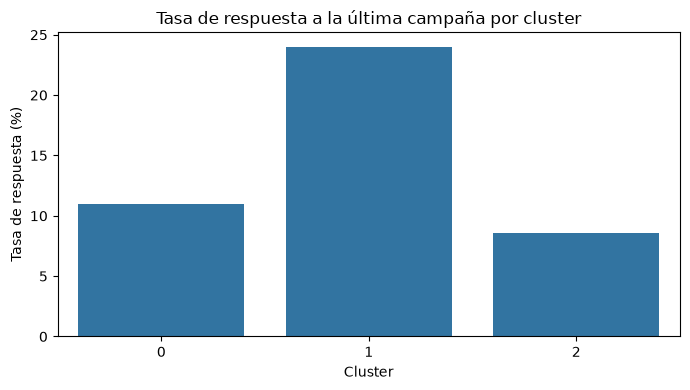

In [26]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=response_profile.reset_index(),
    x="Cluster",
    y="ResponseRate"
)

plt.title("Tasa de respuesta a la última campaña por cluster")
plt.xlabel("Cluster")
plt.ylabel("Tasa de respuesta (%)")

plt.tight_layout()
plt.show()

### 4.2.1 Interpretación de la respuesta a la última campaña

La respuesta a la última campaña presenta diferencias claras entre los tres
clusters.

El **Cluster 1** registra la mayor tasa de respuesta, con un 24,0 % de clientes
que aceptaron la campaña (193 de 803). Esta proporción es más del doble de la
observada en los otros dos grupos.

El **Cluster 0** presenta una tasa de respuesta del 11,0 %, correspondiente a
79 de sus 715 clientes, mientras que el **Cluster 2** registra la menor tasa,
con un 8,6 % y 62 respuestas entre 718 clientes.

El patrón del Cluster 1 es coherente con su mayor aceptación histórica de
campañas observada anteriormente. Sin embargo, los Clusters 0 y 2 muestran una
diferencia respecto al comportamiento histórico agregado: aunque el Cluster 2
presentaba ligeramente más aceptaciones históricas de media, el Cluster 0
obtiene una tasa de respuesta superior en la última campaña.

Por tanto, la respuesta de marketing no depende únicamente de la pertenencia a
un cluster, sino que también puede variar entre campañas. Estas diferencias
deben interpretarse de forma descriptiva, ya que el dataset no proporciona
información suficiente sobre el diseño, la oferta o la selección de audiencia
de cada campaña.

## 5. Comparación entre K-Means y RFM

El proyecto utiliza dos enfoques complementarios de segmentación de clientes.

La segmentación **RFM** clasifica a los clientes según su recencia, frecuencia
de compra y gasto, proporcionando una interpretación principalmente relacionada
con el valor y la actividad comercial.

La segmentación mediante **K-Means** utiliza simultáneamente características
demográficas, económicas y de comportamiento, permitiendo identificar perfiles
multivariables sin establecer previamente reglas de segmentación.

En esta sección se reconstruye la clasificación RFM para analizar cómo se
distribuyen sus segmentos dentro de los clusters obtenidos mediante K-Means y
evaluar qué información complementaria aporta cada metodología.

### 5.1 Reconstrucción de segmentos RFM

Para mantener la comparabilidad con el análisis RFM original, los puntos de
corte se calculan utilizando el dataset preparado completo de 2.240 clientes.

Posteriormente, las puntuaciones y segmentos resultantes se incorporan a la
muestra de 2.236 clientes utilizada en K-Means. De este modo, la exclusión de
cuatro observaciones extremas del modelo de clustering no modifica la definición
original de los segmentos RFM.

In [27]:
rfm_features = [
    "Recency",
    "TotalPurchases",
    "TotalSpend"
]

rfm_quantiles = df[rfm_features].quantile(
    [0.25, 0.50, 0.75]
)

rfm_quantiles

,Recency,TotalPurchases,TotalSpend
0.25,24.0,6.0,68.75
0.50,49.0,12.0,396.00
0.75,74.0,18.0,1045.50


In [28]:
df_rfm = df.copy()

df_rfm["R_Score"] = pd.cut(
    df_rfm["Recency"],
    bins=[-float("inf"), 24, 49, 74, float("inf")],
    labels=[4, 3, 2, 1],
    include_lowest=True
).astype(int)

df_rfm["F_Score"] = pd.cut(
    df_rfm["TotalPurchases"],
    bins=[-float("inf"), 6, 12, 18, float("inf")],
    labels=[1, 2, 3, 4],
    include_lowest=True
).astype(int)

df_rfm["M_Score"] = pd.cut(
    df_rfm["TotalSpend"],
    bins=[-float("inf"), 68.75, 396, 1045.5, float("inf")],
    labels=[1, 2, 3, 4],
    include_lowest=True
).astype(int)

df_rfm["FM_Score"] = (
    df_rfm["F_Score"] + df_rfm["M_Score"]
) / 2

In [29]:
def assign_rfm_segment(row):
    r = row["R_Score"]
    fm = row["FM_Score"]

    if r >= 3 and fm >= 3:
        return "Champions"
    elif r >= 3 and fm >= 2:
        return "Loyal Customers"
    elif r >= 3:
        return "Potential Loyalists"
    elif fm >= 3:
        return "At Risk"
    elif fm >= 2:
        return "Need Attention"
    else:
        return "Hibernating"


df_rfm["RFM_Segment"] = df_rfm.apply(
    assign_rfm_segment,
    axis=1
)

In [30]:
rfm_check = (
    df_rfm["RFM_Segment"]
    .value_counts()
    .to_frame("Customers")
)

rfm_check["Percentage"] = (
    rfm_check["Customers"] / len(df_rfm) * 100
).round(2)

rfm_check

,Customers,Percentage
RFM_Segment,,
At Risk,558,24.91
Champions,535,23.88
Potential Loyalists,378,16.88
Hibernating,360,16.07
Loyal Customers,209,9.33
Need Attention,200,8.93


### 5.2 Distribución RFM dentro de cada cluster

Una vez reproducida la segmentación RFM original, se incorporan sus etiquetas a
los clientes utilizados en K-Means mediante el identificador `ID`.

El cruce permite analizar qué tipos de clientes RFM aparecen dentro de cada
cluster y determinar hasta qué punto ambas metodologías capturan estructuras
similares o complementarias.

In [31]:
df_cluster = df_cluster.merge(
    df_rfm[["ID", "RFM_Segment"]],
    on="ID",
    how="left",
    validate="one_to_one"
)

df_cluster["RFM_Segment"].isna().sum()

np.int64(0)

In [32]:
rfm_cluster_counts = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["RFM_Segment"]
)

rfm_cluster_counts

RFM_Segment,At Risk,Champions,Hibernating,Loyal Customers,Need Attention,Potential Loyalists
Cluster,,,,,,
0,36,47,222,94,75,241
1,404,378,2,8,9,2
2,118,109,135,107,116,133


In [33]:
rfm_cluster_pct = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["RFM_Segment"],
    normalize="index"
).mul(100).round(1)

rfm_cluster_pct

RFM_Segment,At Risk,Champions,Hibernating,Loyal Customers,Need Attention,Potential Loyalists
Cluster,,,,,,
0,5.0,6.6,31.0,13.1,10.5,33.7
1,50.3,47.1,0.2,1.0,1.1,0.2
2,16.4,15.2,18.8,14.9,16.2,18.5


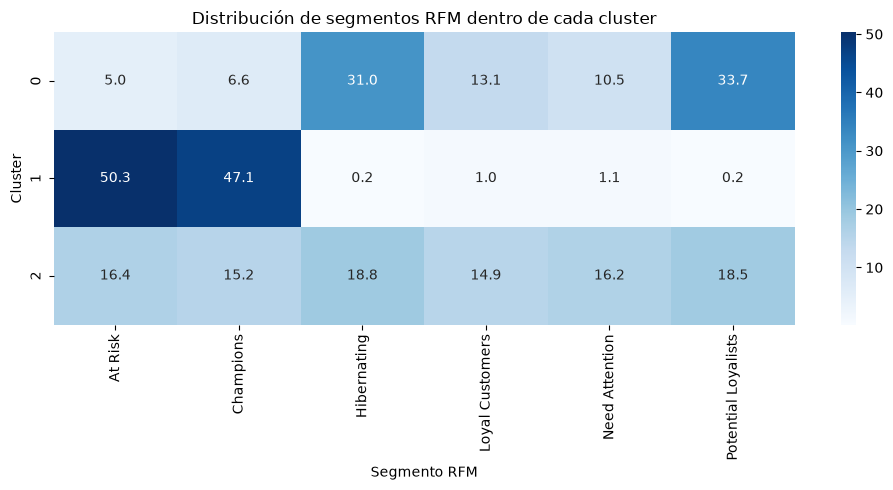

In [34]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    rfm_cluster_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Distribución de segmentos RFM dentro de cada cluster")
plt.xlabel("Segmento RFM")
plt.ylabel("Cluster")

plt.tight_layout()

plt.savefig(
    "../reports/figures/rfm_kmeans_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### 5.3 Relación entre ambas segmentaciones

La comparación entre K-Means y RFM muestra que ambas metodologías capturan
dimensiones diferentes y complementarias del comportamiento de los clientes.

El **Cluster 1** presenta la relación más clara con la segmentación RFM. El
50,3 % de sus clientes pertenece al segmento `At Risk` y el 47,1 % a
`Champions`. En conjunto, estos dos segmentos representan el 97,4 % del cluster.

Este resultado es coherente con el elevado gasto y la elevada intensidad de
compra observados previamente en el Cluster 1. La principal diferencia entre
`Champions` y `At Risk` dentro de este grupo procede de la recencia: RFM permite
distinguir entre clientes de alto valor que han comprado recientemente y
clientes con un historial de alto valor cuya última compra es más lejana.

El **Cluster 0** presenta un patrón muy diferente. Los segmentos más frecuentes
son `Potential Loyalists` (33,7 %) y `Hibernating` (31,0 %), que conjuntamente
representan casi dos tercios del cluster. Los segmentos de mayor frecuencia y
gasto, `Champions` y `At Risk`, tienen una presencia mucho menor, con un 6,6 %
y un 5,0 %, respectivamente.

Este resultado es consistente con el menor gasto y la menor intensidad de
compra observados en el Cluster 0. Sin embargo, RFM introduce una distinción
adicional relevante: dentro de clientes con niveles relativamente bajos de
frecuencia y gasto aparecen tanto clientes recientes (`Potential Loyalists`)
como clientes con una recencia elevada (`Hibernating`).

El **Cluster 2** presenta la distribución RFM más heterogénea. Ningún segmento
supera el 20 % del cluster y los clientes se distribuyen entre `Hibernating`
(18,8 %), `Potential Loyalists` (18,5 %), `At Risk` (16,4 %),
`Need Attention` (16,2 %), `Champions` (15,2 %) y `Loyal Customers` (14,9 %).

Esta heterogeneidad muestra que el Cluster 2 reúne clientes con características
demográficas y económicas similares, pero con diferentes niveles de recencia,
frecuencia y valor comercial.

En conjunto, K-Means y RFM no producen segmentaciones equivalentes. K-Means
permite identificar perfiles considerando simultáneamente características
demográficas, económicas y de comportamiento, mientras que RFM introduce una
clasificación específicamente orientada a la actividad y al valor comercial.

La combinación de ambas perspectivas proporciona una visión más completa del
cliente: K-Means ayuda a comprender **quién es y cómo se comporta el perfil**,
mientras que RFM ayuda a distinguir **su situación comercial actual en función
de recencia, frecuencia y gasto**.

## 6. Definición de perfiles de cliente

Una vez analizadas las características sociodemográficas, el comportamiento de
compra, la respuesta a campañas y la relación con RFM, se construye una síntesis
de los principales rasgos de cada cluster.

El objetivo es transformar las etiquetas numéricas generadas por K-Means en
perfiles interpretables desde una perspectiva de marketing, evitando atribuir
características que no estén respaldadas por los datos.

### 6.1 Características principales

Se seleccionan algunas de las variables más representativas del análisis para
obtener una visión resumida de las diferencias entre clusters.

In [35]:
profile_features = [
    "Age",
    "Income",
    "Children",
    "Recency",
    "TotalSpend",
    "TotalPurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "CampaignAcceptances",
    "Response"
]

cluster_summary = (
    df_cluster
    .groupby("Cluster")[profile_features]
    .mean()
    .round(2)
)

cluster_summary

,Age,Income,Children,Recency,TotalSpend,TotalPurchases,NumDealsPurchases,NumWebVisitsMonth,CampaignAcceptances,Response
Cluster,,,,,,,,,,
0,36.94,31945.28,0.84,47.67,150.60,6.99,2.06,6.68,0.10,0.11
1,46.51,73388.23,0.40,49.69,1286.39,19.62,1.78,3.60,0.62,0.24
2,51.66,47917.50,1.67,49.92,298.52,10.17,3.20,5.88,0.14,0.09


In [36]:
top_rfm_segments = (
    rfm_cluster_pct
    .apply(
        lambda row: ", ".join(
            f"{segment} ({row[segment]:.1f}%)"
            for segment in row.nlargest(2).index
        ),
        axis=1
    )
    .rename("Main_RFM_Segments")
    .to_frame()
)

top_rfm_segments

,Main_RFM_Segments
Cluster,
0,"Potential Loyalists (33.7%), Hibernating (31.0%)"
1,"At Risk (50.3%), Champions (47.1%)"
2,"Hibernating (18.8%), Potential Loyalists (18.5%)"


### 6.2 Nombres de negocio de los segmentos

A partir del perfil conjunto de cada cluster se asignan nombres descriptivos que
facilitan su interpretación desde una perspectiva de negocio.

Los nombres no forman parte del algoritmo K-Means, sino que se asignan
posteriormente a partir de las características observadas en cada grupo.

#### Cluster 0 — Young Low-Value Customers

El Cluster 0 representa el perfil más joven, con una edad media de 36,94 años y
los menores ingresos medios, aproximadamente 31.945.

También presenta el menor gasto total (150,60) y la menor intensidad de compra
(6,99 compras), aunque registra la mayor actividad web, con 6,68 visitas
mensuales de media. El uso relativo de descuentos es elevado en comparación con
el Cluster 1.

Su consumo está más diversificado entre categorías de producto y sus principales
segmentos RFM son `Potential Loyalists` y `Hibernating`, mostrando que dentro de
este perfil existen tanto clientes recientes de bajo valor como clientes con
mayor tiempo desde su última compra.

Por estas características, el grupo se denomina **Young Low-Value Customers**.

#### Cluster 1 — High-Value Customers

El Cluster 1 constituye el grupo de mayor valor comercial observado. Presenta
los mayores ingresos medios, aproximadamente 73.388, el mayor gasto total
(1.286,39) y la mayor intensidad de compra (19,62 compras).

También utiliza de forma más equilibrada los diferentes canales de compra y
presenta una dependencia relativa de los descuentos considerablemente menor que
los otros clusters.

Su respuesta de marketing es especialmente destacable: registra una media de
0,62 campañas históricas aceptadas y una tasa de respuesta del 24,0 % en la
última campaña.

La segmentación RFM divide prácticamente todo el cluster entre `Champions`
(47,1 %) y `At Risk` (50,3 %). Por tanto, el grupo reúne clientes de elevado
valor histórico, aunque con diferencias importantes en la recencia de compra.

Por estas características, el grupo se denomina **High-Value Customers**.

#### Cluster 2 — Family-Oriented Moderate-Value Customers

El Cluster 2 presenta la mayor edad media, con 51,66 años, y el mayor número de
hijos en el hogar, con 1,67 de media. Sus ingresos, aproximadamente 47.918, se
sitúan entre los otros dos grupos.

Su gasto total (298,52) y su intensidad de compra (10,17 compras) también ocupan
una posición intermedia. Presenta el mayor número medio de compras con descuento
y una elevada utilización relativa de promociones.

Su gasto se encuentra especialmente concentrado en vinos, que representan el
60,3 % de su mix de gasto.

A diferencia del Cluster 1, su composición RFM es muy heterogénea y ningún
segmento individual supera el 20 %. Esto indica que clientes con un perfil
demográfico y económico similar pueden encontrarse en situaciones comerciales
muy diferentes.

Por estas características, el grupo se denomina **Family-Oriented Moderate-Value
Customers**.

In [37]:
cluster_names = {
    0: "Young Low-Value Customers",
    1: "High-Value Customers",
    2: "Family-Oriented Moderate-Value Customers"
}

df_cluster["CustomerProfile"] = (
    df_cluster["Cluster"]
    .map(cluster_names)
)

df_cluster[
    ["Cluster", "CustomerProfile"]
].drop_duplicates().sort_values("Cluster")

,Cluster,CustomerProfile
3,0,Young Low-Value Customers
0,1,High-Value Customers
1,2,Family-Oriented Moderate-Value Customers


## 7. Recomendaciones de marketing

Los perfiles identificados permiten formular diferentes líneas de actuación de
marketing adaptadas a las características observadas en cada grupo.

Estas recomendaciones deben interpretarse como hipótesis de negocio derivadas
del análisis descriptivo. Su efectividad debería validarse posteriormente
mediante experimentos controlados, pruebas A/B o análisis de campañas futuras.

### 7.1 Estrategias por perfil

#### Young Low-Value Customers

Este segmento presenta el menor gasto y frecuencia de compra, pero también la
mayor actividad web y un peso relativamente elevado de las compras con
descuento. Además, sus principales segmentos RFM son `Potential Loyalists` y
`Hibernating`.

Una posible estrategia sería orientar las acciones hacia la **activación y el
incremento de la frecuencia de compra**, utilizando ofertas de entrada,
promociones selectivas o incentivos vinculados a una siguiente compra.

Dado su elevado nivel de actividad web, el canal digital puede utilizarse para
probar estas acciones, aunque el número de visitas no debe interpretarse
directamente como intención de compra.

La coexistencia de `Potential Loyalists` y `Hibernating` también sugiere que no
todos los clientes del perfil deberían recibir la misma acción. La recencia
proporcionada por RFM permitiría diferenciar entre clientes recientes con
potencial de desarrollo y clientes inactivos que podrían requerir acciones de
reactivación.

#### High-Value Customers

Este segmento concentra los mayores niveles de gasto e intensidad de compra,
presenta una utilización equilibrada de los canales y muestra la mayor respuesta
histórica y reciente a las campañas de marketing.

Las acciones podrían orientarse principalmente hacia la **retención,
fidelización y desarrollo del valor del cliente**, mediante programas de
fidelización, ofertas exclusivas o acciones de venta cruzada relacionadas con
las categorías de mayor consumo.

La combinación de vinos y productos cárnicos representa una parte importante de
su gasto, por lo que podrían evaluarse campañas de cross-selling entre estas
categorías.

La segmentación RFM resulta especialmente relevante dentro de este perfil. Los
`Champions` podrían recibir acciones orientadas a mantener la relación y
recompensar su fidelidad, mientras que los clientes `At Risk`, que mantienen un
elevado valor histórico pero presentan una mayor recencia, podrían priorizarse
en campañas específicas de reactivación.

#### Family-Oriented Moderate-Value Customers

Este segmento presenta una edad media superior, mayor número de hijos y niveles
intermedios de ingresos, gasto y frecuencia de compra. También registra el mayor
número medio de compras con descuento y una elevada participación relativa de
las promociones.

Su gasto está especialmente concentrado en vinos, mientras que su composición
RFM es heterogénea.

Las acciones podrían orientarse hacia el **incremento del valor de la cesta y la
diversificación del consumo**, evaluando promociones cruzadas entre vinos y
otras categorías de producto.

Dado el peso observado de las compras con descuento, también podrían probarse
promociones segmentadas y paquetes de productos, comparando su rendimiento con
incentivos no basados exclusivamente en precio.

La heterogeneidad RFM de este cluster hace especialmente conveniente utilizar
la recencia y el nivel de actividad como una segunda capa de segmentación antes
de seleccionar una acción comercial concreta.

### 7.2 Validación de las estrategias

Las recomendaciones anteriores se derivan de patrones observados en los datos y
no constituyen evidencia causal sobre la efectividad de una determinada acción
de marketing.

Una implementación real debería validar las estrategias mediante experimentos
controlados o pruebas A/B, utilizando métricas como tasa de respuesta, tasa de
conversión, frecuencia de compra, valor medio de compra e ingresos incrementales.

También sería recomendable analizar los resultados por combinación de perfil
K-Means y segmento RFM. De esta forma podría evaluarse, por ejemplo, si una
estrategia de reactivación produce resultados diferentes entre clientes
`At Risk` pertenecientes a distintos perfiles de K-Means.

Este enfoque permitiría transformar la segmentación descriptiva en un sistema
iterativo de toma de decisiones basado en datos.

## 8. Conclusiones

El análisis de perfilado ha permitido transformar los tres clusters obtenidos
mediante K-Means en segmentos interpretables desde una perspectiva de negocio.

El **Cluster 0, Young Low-Value Customers**, agrupa principalmente clientes más
jóvenes, con menores ingresos, gasto y frecuencia de compra. Presenta una
actividad web elevada y un mayor peso relativo de las compras con descuento.
RFM permite diferenciar dentro de este grupo entre clientes recientes con
potencial de desarrollo y clientes con mayor nivel de inactividad.

El **Cluster 1, High-Value Customers**, concentra los clientes con mayores
ingresos, gasto e intensidad de compra. También presenta la mayor respuesta a
campañas y una utilización más equilibrada de los canales. RFM introduce una
distinción especialmente relevante dentro de este grupo entre `Champions` y
`At Risk`, separando clientes de alto valor según su recencia de compra.

El **Cluster 2, Family-Oriented Moderate-Value Customers**, presenta clientes de
mayor edad, hogares con más hijos y niveles intermedios de ingresos, gasto y
frecuencia de compra. Destaca por un mayor uso de descuentos y una fuerte
concentración del gasto en vinos. Su elevada heterogeneidad RFM indica que el
perfil general debe complementarse con información sobre la situación comercial
de cada cliente.

La comparación entre metodologías muestra que **K-Means y RFM aportan
perspectivas complementarias**. K-Means identifica perfiles multivariables a
partir de características demográficas, económicas y de comportamiento,
mientras que RFM facilita la interpretación de la situación comercial mediante
recencia, frecuencia y gasto.

En un contexto de marketing, ambas segmentaciones podrían utilizarse de forma
conjunta: el perfil K-Means como descripción general del cliente y RFM como una
segunda capa para adaptar las acciones según su nivel de actividad y valor
comercial.

Finalmente, las estrategias propuestas deben considerarse hipótesis de negocio.
Su impacto debería validarse mediante campañas controladas y métricas de
respuesta, conversión e ingresos incrementales antes de convertirlas en
decisiones operativas.